In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import torch
from ipywidgets import interact

print(torch.version.cuda)
print(torch.cuda.is_available())

None
False


In [2]:

def directed_random_walk_diffusion_expm(
    x: torch.Tensor,  # shape (N,) or (N,C)
    d: torch.Tensor,  # shape (N,N), directed distances d[i,j]
    s: float,         # diffusion time (0 < s < 1)
    sigma: float,     # kernel scale (> 0)
) -> torch.Tensor:
    """One-step directed random-walk diffusion smoothing via matrix exponential.

    Defines:
      K_ij = exp(-d_ij / sigma)
      P_ij = K_ij / sum_j K_ij           (row-stochastic)
      L    = I - P                       (random-walk Laplacian / generator)
      x'   = exp(-t * L) @ x             (closed-form diffusion at time t)

    Args:
      x: Values at N samples. Shape (N,) or (N,C).
      d: Directed distance matrix. Shape (N,N).
      s: Diffusion time/strength (0 < s < 1).
      sigma: Kernel scale.

    Returns:
      Smoothed x with the same shape as input.
    """
    t = s / (1 - s)  # Reparameterize s in (0,1) to t in (0,inf)
    K = torch.exp(-d / sigma)                           # (N,N)
    P = K / K.sum(dim=1, keepdim=True)                  # (N,N)
    N = d.shape[0]
    L = torch.eye(N, device=d.device, dtype=d.dtype) - P  # (N,N)
    return torch.linalg.matrix_exp(-t * L) @ x          # (N,) or (N,C)

AssertionError: Torch not compiled with CUDA enabled

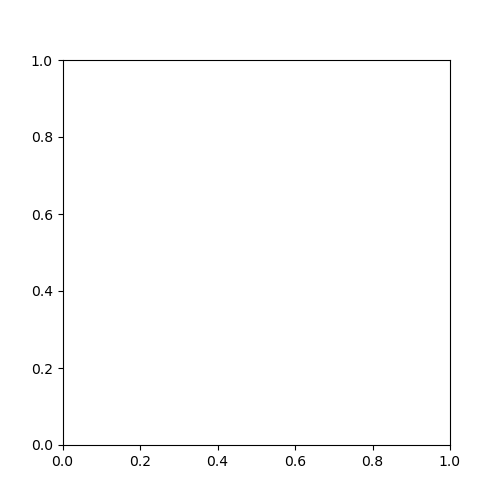

In [3]:

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

torch.manual_seed(0)
data = torch.rand(20, 2, device='cuda')

@interact(s=(0.01, 0.99, 0.01), sigma=(0.01, 2.0, 0.01))
def show(s, sigma):
    ax.clear()
    ax.scatter(data[:, 0], data[:, 1], marker='o', s=10, color='gray', alpha=0.25)
    dists = torch.norm(data[:, None, :] - data[None, :, :], dim=-1)  # (N,N)
    data_transformed = directed_random_walk_diffusion_expm(
        x=data,
        d=dists,
        s=s,
        sigma=sigma
    )
    ax.scatter(data_transformed[:, 0], data_transformed[:, 1], marker='o', s=10)
    ax.set_title(f"s={s:.2f}, sigma={sigma}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)